In [ ]:
# Kaggle API kimlik doğrulaması ve veri setinin indirilmesi
from google.colab import files
import os

print("Lütfen kaggle.json dosyanızı yükleyin:")
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Veri seti Kaggle'dan indiriliyor...")
!kaggle datasets download -d asdasdasasdas/garbage-classification
!unzip -q garbage-classification.zip -d dataset/

print("✅ Veri seti başarıyla indirildi!")

Lütfen kaggle.json dosyanızı yükleyin:


cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Veri seti Kaggle'dan indiriliyor...
Dataset URL: https://www.kaggle.com/datasets/asdasdasasdas/garbage-classification
License(s): copyright-authors
100% 82.0M/82.0M [00:00<00:00, 139MB/s]

✅ Veri seti başarıyla indirildi!


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

data_dir = 'dataset/Garbage classification/Garbage classification'
# EfficientNetB3 300x300 girişi sever, kapasitesini artırmak için kullanıyoruz
img_size = (300, 300)
batch_size = 16 # Model güçlü olduğu için batch size'ı küçültüyoruz

# Eğitim ve Doğrulama Setleri
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset="training", seed=123,
    image_size=img_size, batch_size=batch_size)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset="validation", seed=123,
    image_size=img_size, batch_size=batch_size)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"✅ Sınıflar Tanımlandı: {class_names}")

# Geometriyi çok bozmadan güvenli artırma
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
  layers.RandomContrast(0.2),
  layers.RandomZoom(0.2), # Eklenen: Detayları daha iyi anlaması için
])

Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.
✅ Sınıflar Tanımlandı: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [ ]:
# 1. Yeni omurga ağımız: EfficientNetB3
base_model = tf.keras.applications.EfficientNetB3(
    input_shape=(300, 300, 3),
    include_top=False,
    weights='imagenet'
)

# Temel ağırlıkları ilk aşama için donduruyoruz
base_model.trainable = False

# 2. Atık Sınıflandırıcımız (EfficientNet için optimize edildi)
model = tf.keras.Sequential([
  data_augmentation,
  base_model,
  layers.GlobalAveragePooling2D(),
  layers.BatchNormalization(), # Stabilite için kritik
  layers.Dense(256, activation='relu'),
  layers.Dropout(0.4), # Ezberlemeyi önlemek için artırdık
  layers.Dense(num_classes, activation='softmax')
])

# Hassas başlangıç hızı
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("✅ EfficientNetB3 Mimarisi Elite Seviyede Kuruldu!")
model.summary()

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ EfficientNetB3 Mimarisi Elite Seviyede Kuruldu!


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,783,535 (41.14 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 10,783,535 (41.14 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Akıllı Fren ve Hız Düşürücü
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1)

print("🚀 Aşama 1: Temel Eğitim Başlıyor...")
# EfficientNetB3 eğitim zamanı alabilir, sabırlı ol
history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15, # Temeli sağlam atmak için 15 tur yeterli
    callbacks=[early_stop, lr_reducer]
)
print("✅ Temel Eğitim Tamamlandı!")

🚀 Aşama 1: Temel Eğitim Başlıyor...
Epoch 1/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 49s 214ms/step - accuracy: 0.7285 - loss: 0.9164 - val_accuracy: 0.8733 - val_loss: 0.3903 - learning_rate: 0.0010
Epoch 2/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 30s 168ms/step - accuracy: 0.8388 - loss: 0.5348 - val_accuracy: 0.8891 - val_loss: 0.3058 - learning_rate: 0.0010
Epoch 3/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 21s 169ms/step - accuracy: 0.8576 - loss: 0.4220 - val_accuracy: 0.9010 - val_loss: 0.3079 - learning_rate: 0.0010
Epoch 4/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.8732 - loss: 0.4010
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
127/127 ━━━━━━━━━━━━━━━━━━━━ 41s 172ms/step - accuracy: 0.8709 - loss: 0.4008 - val_accuracy: 0.8871 - val_loss: 0.3102 - learning_rate: 0.0010
Epoch 5/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 22s 172ms/step - accuracy: 0.8947 - loss: 0.3065 - val_accuracy: 0.9149 - val_loss: 0.2710 - learning_rate: 5.0000e-04
Epoch 6/15
127/127 ━━━━━━━━━━━━━

In [ ]:
# Tüm katmanların kilidini açıyoruz
base_model.trainable = True

# KİLİT NOKTA: Yıkıcı unutmayı engellemek için
# EfficientNetB3 içindeki tüm BatchNormalization katmanlarına kilit vuruyoruz!
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# Çok düşük bir hız ($1 \times 10^{-5}$) ile hassas derleme
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("🎯 Aşama 2: Safe Fine-Tuning 2.0 Başlıyor. Model uzmanlaşıyor...")
history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop, lr_reducer]
)
print("✅ Elite İnce Ayar Tamamlandı!")

🎯 Aşama 2: Safe Fine-Tuning 2.0 Başlıyor. Model uzmanlaşıyor...
Epoch 1/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 99s 488ms/step - accuracy: 0.9575 - loss: 0.1426 - val_accuracy: 0.9287 - val_loss: 0.2310 - learning_rate: 1.0000e-05
Epoch 2/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 56s 445ms/step - accuracy: 0.9515 - loss: 0.1375 - val_accuracy: 0.9366 - val_loss: 0.2169 - learning_rate: 1.0000e-05
Epoch 3/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 56s 445ms/step - accuracy: 0.9570 - loss: 0.1125 - val_accuracy: 0.9366 - val_loss: 0.2150 - learning_rate: 1.0000e-05
Epoch 4/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 57s 447ms/step - accuracy: 0.9624 - loss: 0.1001 - val_accuracy: 0.9426 - val_loss: 0.2112 - learning_rate: 1.0000e-05
Epoch 5/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 57s 445ms/step - accuracy: 0.9649 - loss: 0.0891 - val_accuracy: 0.9406 - val_loss: 0.2035 - learning_rate: 1.0000e-05
Epoch 6/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 57s 445ms/step - accuracy: 0.9748 - loss: 0.0767 - val_accuracy: 0.9406 - val_loss: 0.2090 - learning

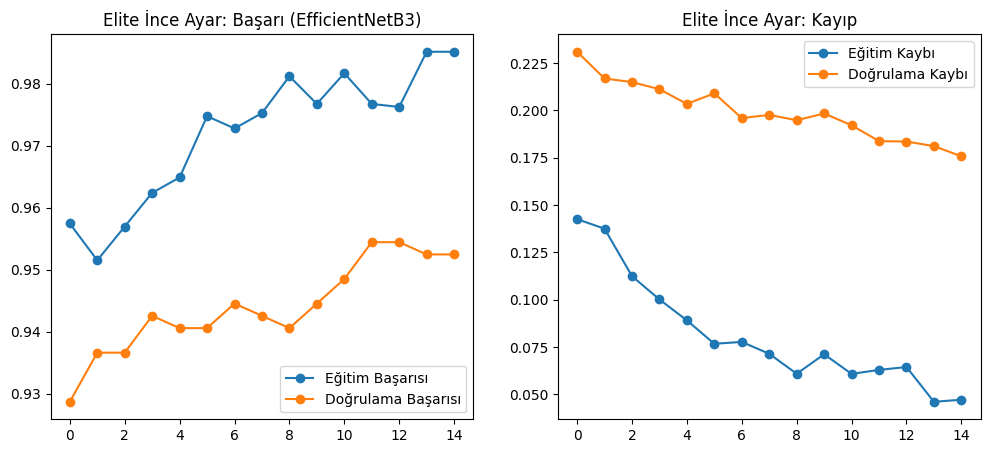

📊 Karmaşıklık Matrisi Hesaplanıyor...

--- Final Sınıflandırma Raporu ---
              precision    recall  f1-score   support

   cardboard     1.0000    0.9518    0.9753        83
       glass     0.9800    0.9515    0.9655       103
       metal     0.9620    0.9744    0.9682        78
       paper     0.9516    0.9516    0.9516       124
     plastic     0.9032    0.9545    0.9282        88
       trash     0.8667    0.8966    0.8814        29

    accuracy                         0.9525       505
   macro avg     0.9439    0.9467    0.9450       505
weighted avg     0.9537    0.9525    0.9528       505



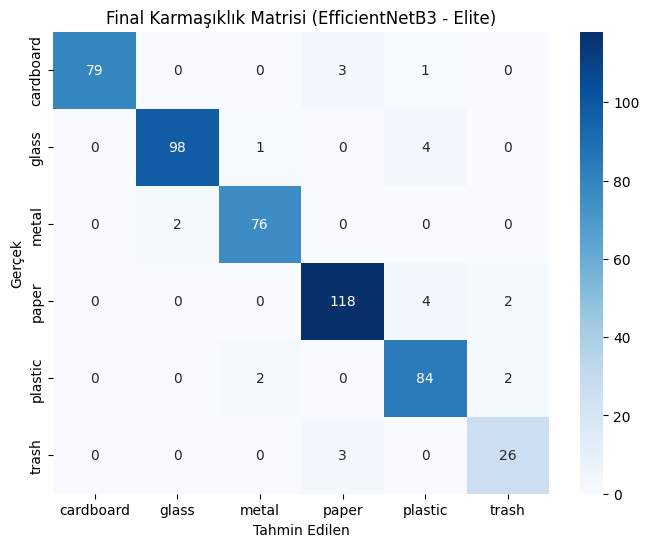

💾 Model 'Garbage_Classification_EfficientNet_Elite.h5' olarak kaydedildi!


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# İnce Ayar Grafikleri
acc = history_stage2.history['accuracy']
val_acc = history_stage2.history['val_accuracy']
loss = history_stage2.history['loss']
val_loss = history_stage2.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Eğitim Başarısı', marker='o')
plt.plot(epochs_range, val_acc, label='Doğrulama Başarısı', marker='o')
plt.legend(loc='lower right')
plt.title('Elite İnce Ayar: Başarı (EfficientNetB3)')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Eğitim Kaybı', marker='o')
plt.plot(epochs_range, val_loss, label='Doğrulama Kaybı', marker='o')
plt.legend(loc='upper right')
plt.title('Elite İnce Ayar: Kayıp')
plt.show()

# Matris ve Rapor
print("📊 Karmaşıklık Matrisi Hesaplanıyor...")
y_true, y_pred_probs = [], []
for images, labels in val_ds:
    y_true.extend(labels.numpy())
    y_pred_probs.extend(model.predict(images, verbose=0))

y_true = np.array(y_true)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

print("\n--- Final Sınıflandırma Raporu ---")
print(classification_report(y_true, y_pred_classes, target_names=class_names, digits=4))

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_true, y_pred_classes), annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek')
plt.title('Final Karmaşıklık Matrisi (EfficientNetB3 - Elite)')
plt.show()

# Final Modeli Kaydet
model.save('Garbage_Classification_EfficientNet_Elite.h5')
print("💾 Model 'Garbage_Classification_EfficientNet_Elite.h5' olarak kaydedildi!")

In [ ]:
!pip install -q gradio
import gradio as gr
import tensorflow as tf
import numpy as np

def predict_image(img):
    img = tf.image.resize(img, (300, 300)) # Yeni model 300x300 girişi sever
    img = tf.expand_dims(img, 0)
    prediction = model.predict(img)[0]
    confidences = {class_names[i]: float(prediction[i]) for i in range(len(class_names))}
    return confidences

demo = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="numpy", label="Test Etmek İçin Atık Fotoğrafı Yükle"),
    outputs=gr.Label(num_top_classes=3, label="Yapay Zekanın Analizi"),
    title="♻️ Atık Tespit Sistemi - Elite V2.0",
    description="Sivas Cumhuriyet Üniversitesi - Derin Öğrenme Projesi (EfficientNetB0 Safe Fine-Tuned)",
    theme="default"
)

demo.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://3cb2b15286bae4d879.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


In [ ]:
import tensorflow as tf

# Kaydettiğimiz zeki modeli geri çağırıyoruz (Sıfırdan eğitime GEREK YOK!)
model = tf.keras.models.load_model('Garbage_Classification_EfficientNet_Elite.h5')

class_names = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
print("Model başarıyla yüklendi ve teste hazır!")

Model başarıyla yüklendi ve teste hazır!
